# Question 1: Watts–Strogatz Small-World Network Model

The WS model creates networks with small-world properties by starting with a regular ring lattice and randomly rewiring edges with probability $p$.

As $p$ goes from 0 to 1, the network transitions from regular → small-world → random.

We compute the **scaled clustering coefficient** $C(p)/C(0)$ and **scaled characteristic path length** $L(p)/L(0)$ to capture this transition.

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def watts_strogatz_manual(n, k, p):
    G = nx.Graph()
    nodes = list(range(n))
    G.add_nodes_from(nodes)

    # Step 1: Create regular ring lattice
    for i in range(n):
        for j in range(1, k//2 + 1):
            G.add_edge(i, (i + j) % n)

    # Step 2: Rewire edges with probability p
    for i in range(n):
        for j in range(1, k//2 + 1):
            if np.random.rand() < p:
                neighbor = (i + j) % n

                # Remove existing edge
                if G.has_edge(i, neighbor):
                    G.remove_edge(i, neighbor)

                # Add new edge avoiding self-loops & duplicates
                new_node = np.random.choice(nodes)
                while new_node == i or G.has_edge(i, new_node):
                    new_node = np.random.choice(nodes)

                G.add_edge(i, new_node)

    return G

## Computing Scaled Metrics

Parameters: $n = 1000$, $k = 10$, $p$ from $10^{-4}$ to $1$ (log scale, 20 points). Each value of $p$ averaged over 10 runs.

First we get $C(0)$ and $L(0)$ at $p=0$ (regular lattice) as baselines.

In [2]:
def compute_metrics(G):
    # Clustering coefficient
    C = nx.average_clustering(G)

    # Characteristic path length
    if nx.is_connected(G):
        L = nx.average_shortest_path_length(G)
    else:
        # Use largest connected component
        Gcc = G.subgraph(max(nx.connected_components(G), key=len))
        L = nx.average_shortest_path_length(Gcc)

    return C, L

n = 1000     # large n captures small-world behavior
k = 10      # k << n ensures sparse network

# Log-scale probabilities (important!)
p_values = np.logspace(-4, 0, 20)

G0 = watts_strogatz_manual(n, k, 0)
C0, L0 = compute_metrics(G0)

print("C(0):", C0)
print("L(0):", L0)

C(0): 0.6666666666666666
L(0): 50.450450450450454


In [3]:
C_vals = []
L_vals = []

runs = 10

for p in p_values:
    C_temp = []
    L_temp = []

    for _ in range(runs):
        G = watts_strogatz_manual(n, k, p)
        C, L = compute_metrics(G)

        C_temp.append(C)
        L_temp.append(L)

    # Take average
    C_avg = np.mean(C_temp)
    L_avg = np.mean(L_temp)

    C_vals.append(C_avg / C0)
    L_vals.append(L_avg / L0)

    print(f"p={p:.5f} | C/C0={C_avg/C0:.3f} | L/L0={L_avg/L0:.3f}")

p=0.00010 | C/C0=1.000 | L/L0=0.932
p=0.00016 | C/C0=0.999 | L/L0=0.792
p=0.00026 | C/C0=0.999 | L/L0=0.846
p=0.00043 | C/C0=0.999 | L/L0=0.866
p=0.00070 | C/C0=0.998 | L/L0=0.633
p=0.00113 | C/C0=0.997 | L/L0=0.529
p=0.00183 | C/C0=0.994 | L/L0=0.384
p=0.00298 | C/C0=0.992 | L/L0=0.326
p=0.00483 | C/C0=0.986 | L/L0=0.247
p=0.00785 | C/C0=0.980 | L/L0=0.207
p=0.01274 | C/C0=0.964 | L/L0=0.162
p=0.02069 | C/C0=0.937 | L/L0=0.133
p=0.03360 | C/C0=0.909 | L/L0=0.118
p=0.05456 | C/C0=0.851 | L/L0=0.102
p=0.08859 | C/C0=0.769 | L/L0=0.091
p=0.14384 | C/C0=0.637 | L/L0=0.082
p=0.23357 | C/C0=0.455 | L/L0=0.074
p=0.37927 | C/C0=0.248 | L/L0=0.069
p=0.61585 | C/C0=0.069 | L/L0=0.066
p=1.00000 | C/C0=0.014 | L/L0=0.065


## Plot: Scaled C(p)/C(0) and L(p)/L(0)

Replicating the classic WS plot — x-axis is $p$ on log scale, y-axis is the normalized metrics.

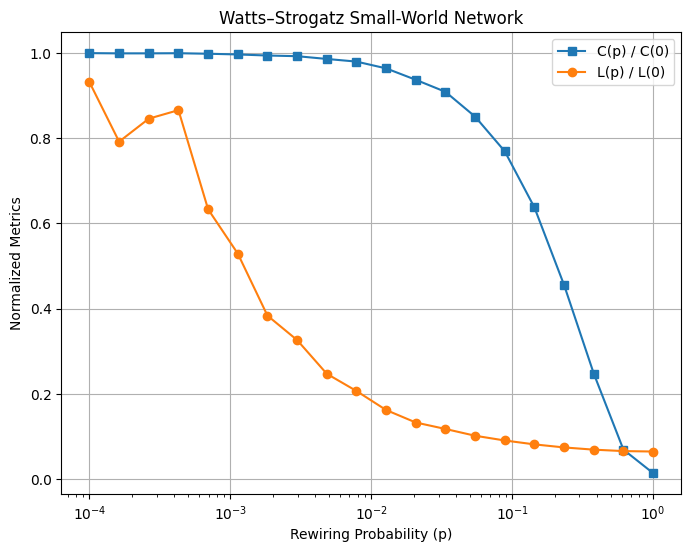

Figure saved: ws_scaled_metrics.png


In [4]:
plt.figure(figsize=(8,6))

# Clustering coefficient
plt.semilogx(p_values, C_vals, 's-', label='C(p) / C(0)')

# Path length
plt.semilogx(p_values, L_vals, 'o-', label='L(p) / L(0)')

plt.xlabel('Rewiring Probability (p)')
plt.ylabel('Normalized Metrics')
plt.title('Watts–Strogatz Small-World Network')

plt.legend()
plt.grid(True)

plt.savefig('ws_scaled_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: ws_scaled_metrics.png")

## Network Visualisation

Small examples ($n=30, k=4$) showing the structural change as $p$ increases.

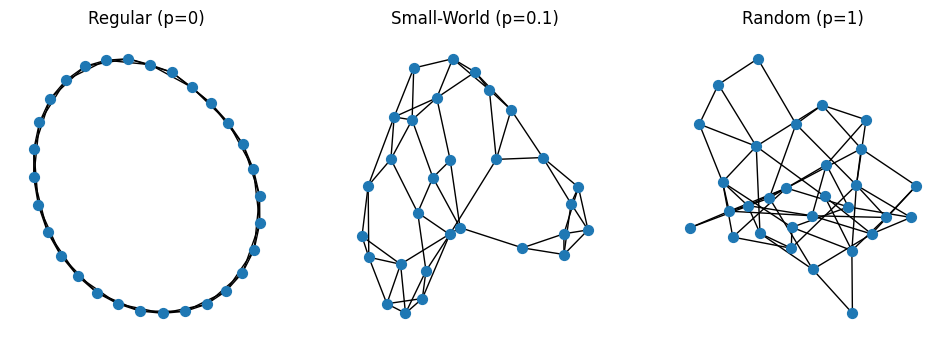

Figure saved: ws_network_visualisation.png


In [5]:
plt.figure(figsize=(12,4))

# Regular
G_reg = watts_strogatz_manual(30, 4, 0)
plt.subplot(1,3,1)
nx.draw(G_reg, node_size=50)
plt.title("Regular (p=0)")

# Small-world
G_sw = watts_strogatz_manual(30, 4, 0.1)
plt.subplot(1,3,2)
nx.draw(G_sw, node_size=50)
plt.title("Small-World (p=0.1)")

# Random
G_rand = watts_strogatz_manual(30, 4, 1)
plt.subplot(1,3,3)
nx.draw(G_rand, node_size=50)
plt.title("Random (p=1)")

plt.savefig('ws_network_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: ws_network_visualisation.png")

## Interpretation

- At $p=0$: high clustering ($C(0) \approx 0.67$) but long paths ($L(0) \approx 50.5$).
- $L$ drops fast with even small $p$ — a few random shortcuts go a long way.
- $C$ stays high until around $p \approx 0.1$ since most edges remain local.
- The small-world regime is roughly $0.01 \lesssim p \lesssim 0.1$ where $L$ is already low but $C$ is still high.